In [41]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


In [42]:
data = pd.read_csv('PD_complete(in).csv', delimiter=';')


In [ ]:
# anonymizing column names
import pandas as pd

# Rename columns to Feature1, Feature2, etc.
data.columns = [f'Feature{i+1}' for i in range(len(data.columns))]

#show the new column names
print(data.columns)


Index(['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6',
       'Feature7', 'Feature8', 'Feature9', 'Feature10', 'Feature11',
       'Feature12', 'Feature13', 'Feature14'],
      dtype='object')


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature1   376 non-null    int64  
 1   Feature2   376 non-null    int64  
 2   Feature3   376 non-null    int64  
 3   Feature4   376 non-null    int64  
 4   Feature5   376 non-null    int64  
 5   Feature6   376 non-null    int64  
 6   Feature7   376 non-null    int64  
 7   Feature8   376 non-null    int64  
 8   Feature9   376 non-null    float64
 9   Feature10  376 non-null    object 
 10  Feature11  376 non-null    object 
 11  Feature12  376 non-null    object 
 12  Feature13  376 non-null    object 
 13  Feature14  376 non-null    object 
dtypes: float64(1), int64(8), object(5)
memory usage: 41.3+ KB


In [43]:
#data

In [ ]:
target_column ='Feature13'      

In [7]:
data.isnull().sum()

Feature1     0
Feature2     0
Feature3     0
Feature4     0
Feature5     0
Feature6     0
Feature7     0
Feature8     0
Feature9     0
Feature10    0
Feature11    0
Feature12    0
Feature13    0
Feature14    0
dtype: int64

#### Drop rows when target column is Missing connection types

In [ ]:
data = data[data['Feature13'] != 'Missing connection types']  
data = data[data['Feature11']!='Übergangsmuffe XLPE auf Papier-Masse']  

In [9]:
# Covert to numeric
data[target_column] = pd.to_numeric(data[target_column], errors='coerce')

In [10]:
# find out columns of object dtypes
object_cols = data.select_dtypes(include=["object"]).columns
# get distinct values
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'Feature10' column:
['01. Aug' '01. Jul' '01. Mrz' '1.0' '01. Mai']
------------------------------
Distinct values in 'Feature11' column:
['VPE-Kabel' 'Papier-Masse-Kabel' 'Übergangsmuffe Papier-Masse auf (V)PE'
 'Übergangsmuffe (V)PE auf Papier-Masse' 'Endverschluss'
 'Übergangsmuffe Papier-Masse auf Papier-Masse']
------------------------------
Distinct values in 'Feature12' column:
['Linie' 'Glocke symmetrisch' 'Bar' 'Glocke links' 'Glocke rechts']
------------------------------
Distinct values in 'Feature14' column:
['XLPE' 'Papier-Masse' 'Mischkabel']
------------------------------


In [11]:
enc = LabelEncoder()
for col in object_cols:
    data[col] = enc.fit_transform(data[col])

In [12]:
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'Feature10' column:
[0 1 3 4 2]
------------------------------
Distinct values in 'Feature11' column:
[2 1 4 3 0 5]
------------------------------
Distinct values in 'Feature12' column:
[4 3 0 1 2]
------------------------------
Distinct values in 'Feature14' column:
[2 1 0]
------------------------------


           Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  \
Feature1   1.000000  0.855491  0.998556  0.814342 -0.023445  0.789533   
Feature2   0.855491  1.000000  0.854950  0.922674 -0.029558  0.956203   
Feature3   0.998556  0.854950  1.000000  0.815785 -0.019262  0.788338   
Feature4   0.814342  0.922674  0.815785  1.000000  0.015637  0.775709   
Feature5  -0.023445 -0.029558 -0.019262  0.015637  1.000000 -0.040713   
Feature6   0.789533  0.956203  0.788338  0.775709 -0.040713  1.000000   
Feature7   0.076797  0.193469  0.080524  0.138277 -0.031883  0.212611   
Feature8  -0.070727 -0.145168 -0.073950  0.034121 -0.038485 -0.287546   
Feature9  -0.191828 -0.230187 -0.183226 -0.201857  0.050225 -0.228531   
Feature10 -0.334280 -0.461651 -0.338314 -0.247585  0.091829 -0.567147   
Feature11  0.072454  0.132608  0.069084  0.121289 -0.005508  0.122308   
Feature12  0.119799  0.209863  0.113933  0.182845 -0.019229  0.221162   
Feature13 -0.071254  0.003562 -0.074727  0.029665 -

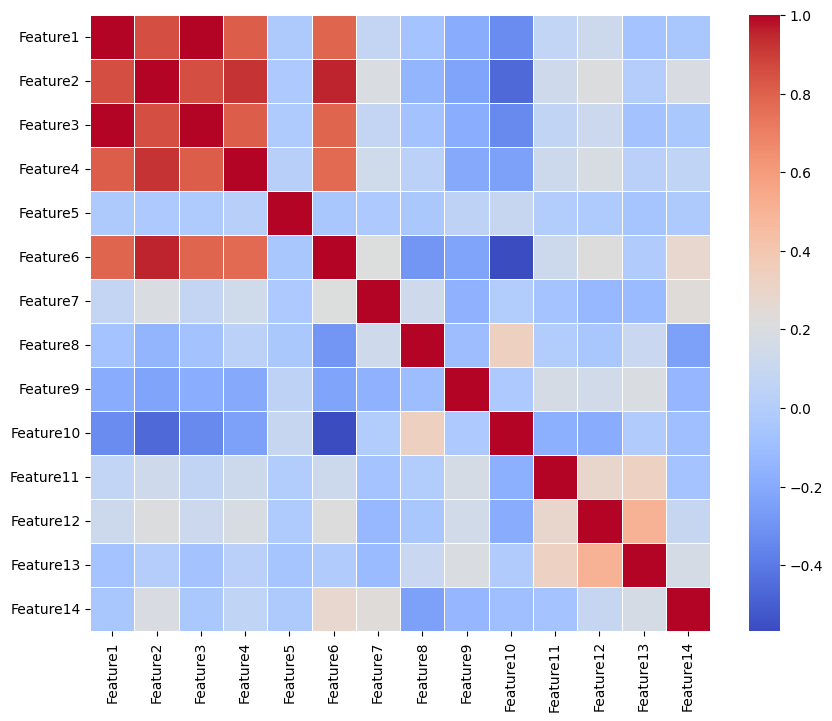

In [13]:
correlation_matrix = data.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

           Feature5  Feature6  Feature7  Feature8  Feature9  Feature10  \
Feature5   1.000000 -0.040713 -0.031883 -0.038485  0.050225   0.091829   
Feature6  -0.040713  1.000000  0.212611 -0.287546 -0.228531  -0.567147   
Feature7  -0.031883  0.212611  1.000000  0.135080 -0.162202  -0.006042   
Feature8  -0.038485 -0.287546  0.135080  1.000000 -0.104390   0.337474   
Feature9   0.050225 -0.228531 -0.162202 -0.104390  1.000000  -0.033049   
Feature10  0.091829 -0.567147 -0.006042  0.337474 -0.033049   1.000000   
Feature11 -0.005508  0.122308 -0.066390 -0.008454  0.168863  -0.176032   
Feature12 -0.019229  0.221162 -0.128063 -0.047125  0.145216  -0.193420   
Feature13 -0.060055 -0.011970 -0.119509  0.101877  0.196952  -0.013546   
Feature14 -0.025595  0.277676  0.231345 -0.243605 -0.138574  -0.090666   

           Feature11  Feature12  Feature13  Feature14  
Feature5   -0.005508  -0.019229  -0.060055  -0.025595  
Feature6    0.122308   0.221162  -0.011970   0.277676  
Feature7   -0.066

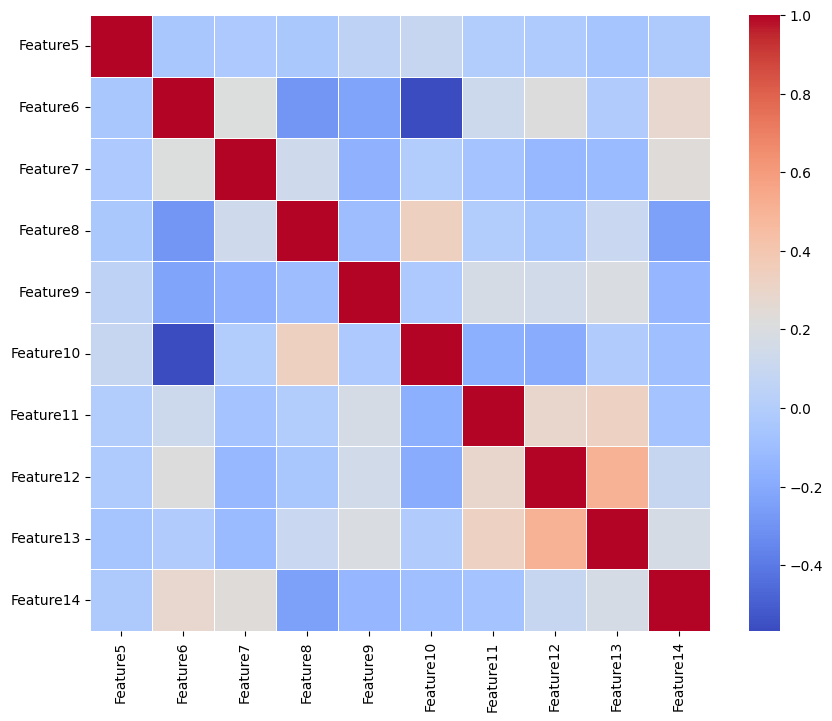

In [ ]:
#dropping id columns
data_for_analysis = data.drop(['Feature1', 'Feature2', 'Feature3', 'Feature4'], axis=1)
correlation_matrix = data_for_analysis.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

In [44]:
#data_for_analysis

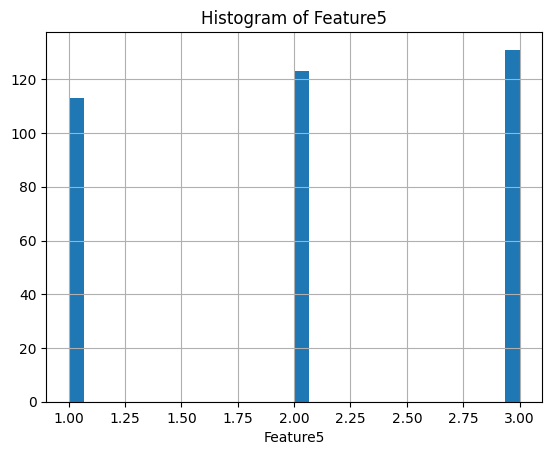

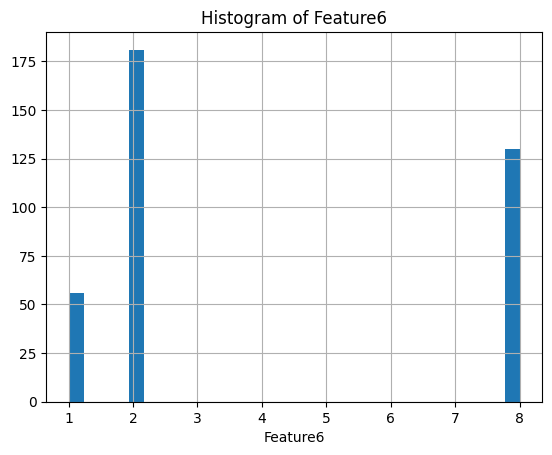

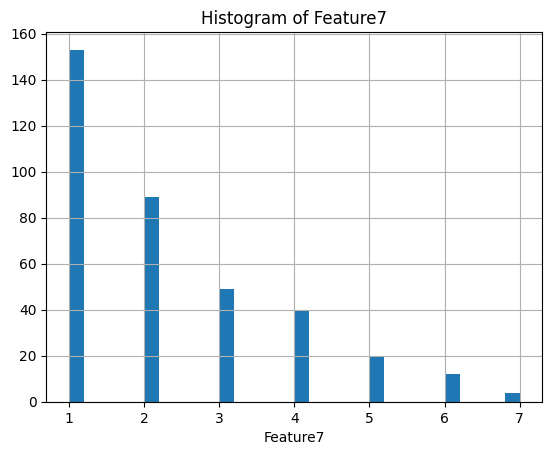

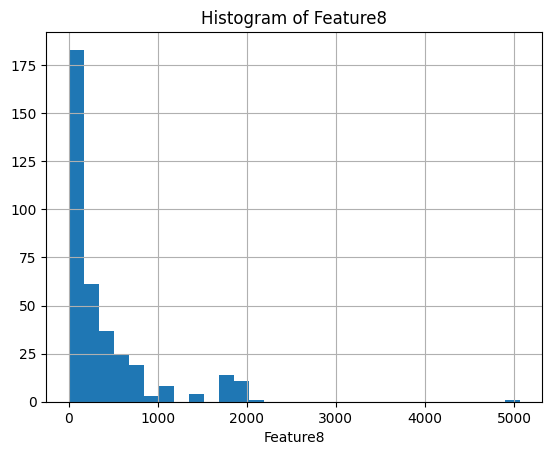

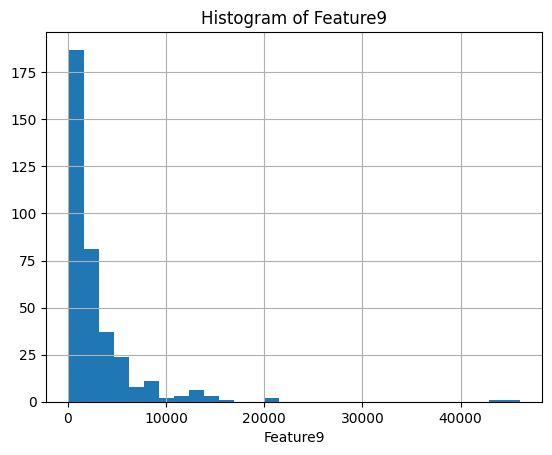

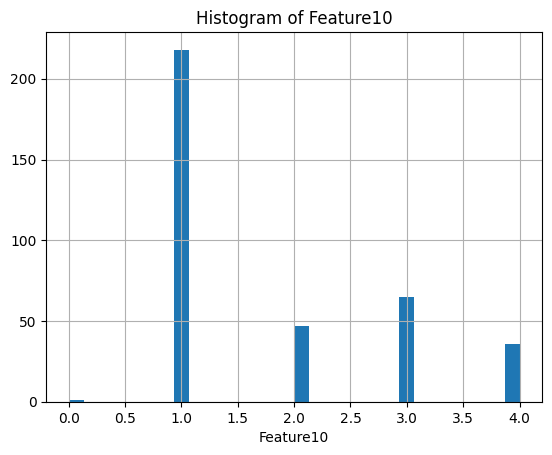

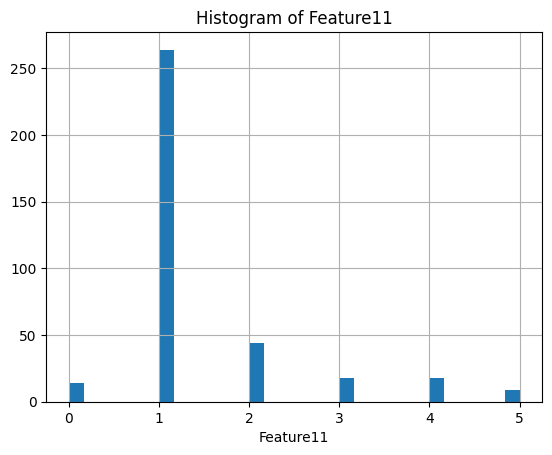

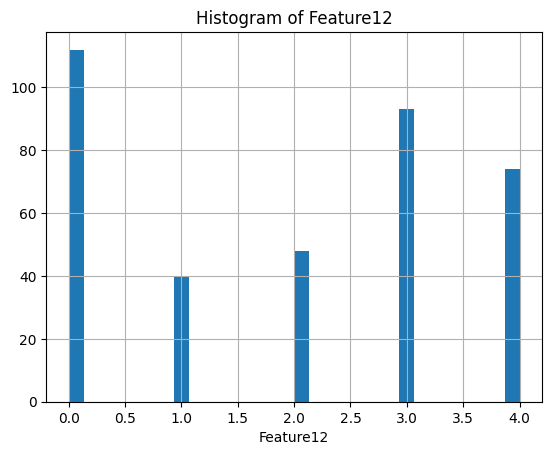

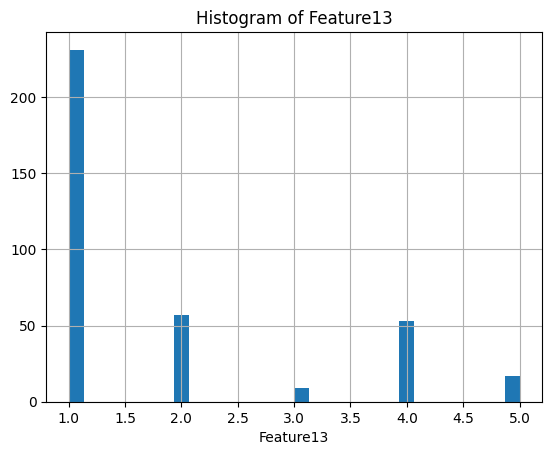

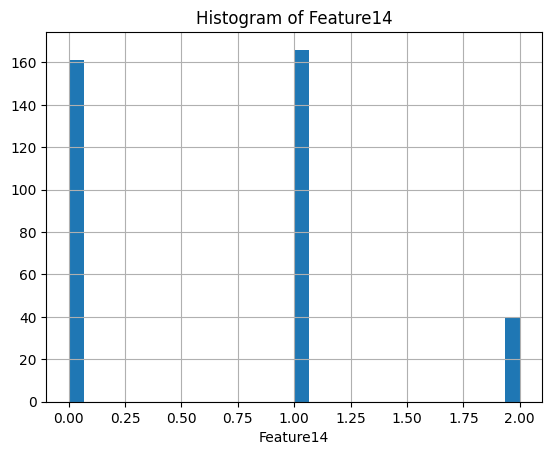

In [16]:
for col in data_for_analysis.columns:
    data_for_analysis[col].hist(bins=30)
    plt.xlabel(col)
    plt.title(f'Histogram of {col}')
    plt.show()

In [17]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column],axis=1)

In [18]:
def make_mi_scores(X, y):
    mi_scores = mutual_info_regression(X.values, y.values)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [19]:
mi_scores = make_mi_scores(x, y)

In [ ]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    
    plt.figure(dpi=120, figsize=(18, 18))
    bars = plt.barh(width, scores)
    
    plt.yticks(width, ticks)
    plt.xlabel("MI Scores")
    plt.title("Mutual Information Scores")
    
    # Add value annotations to each bar
    for bar in bars:
        plt.gca().text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
                       f'{bar.get_width():.2f}', ha='left', va='center')
    
    plt.show()

<Figure size 2400x2400 with 0 Axes>

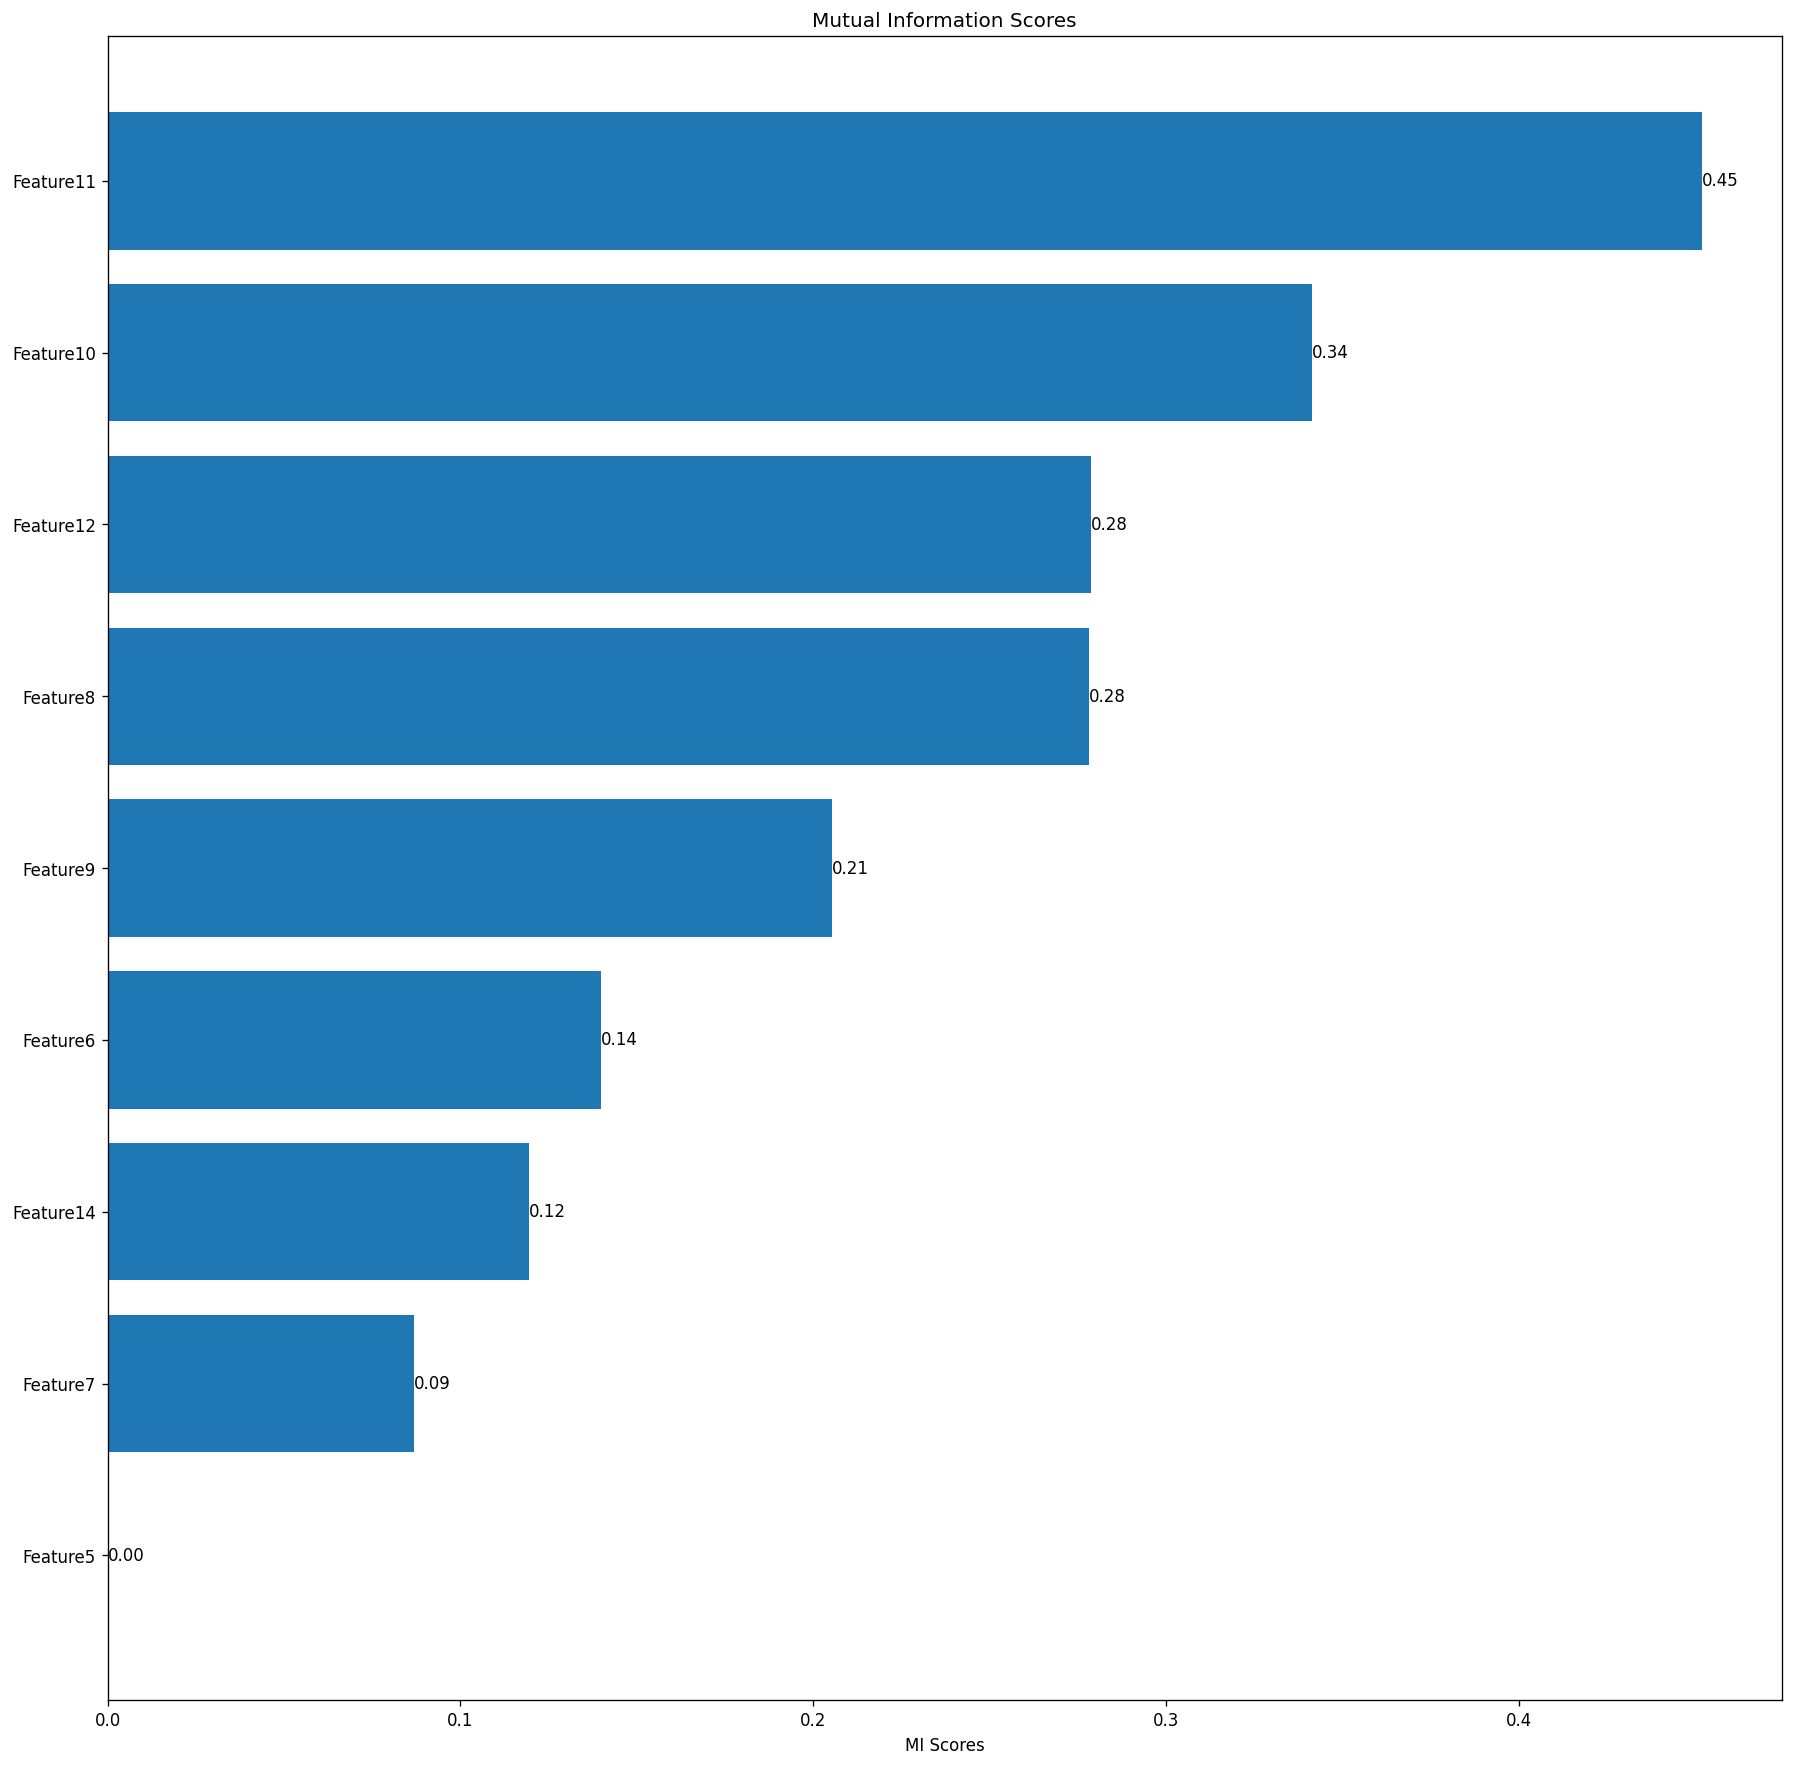

In [21]:
plt.figure(dpi=120, figsize=(20, 20))
plot_mi_scores(mi_scores)

In [22]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Initialize and train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Get feature importances
feature_importances = model.feature_importances_

# Map feature importance to feature names
feature_importance_df = pd.DataFrame(
    {"feature": x.columns, "importance": feature_importances}
)
feature_importance_df = feature_importance_df.sort_values(
    by="importance", ascending=False
)
print(feature_importance_df)

     feature  importance
6  Feature11    0.398115
7  Feature12    0.354750
4   Feature9    0.104070
5  Feature10    0.058223
8  Feature14    0.034423
3   Feature8    0.029126
1   Feature6    0.009648
2   Feature7    0.008368
0   Feature5    0.003277


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23240\1957462479.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df['importance'], y=feature_importance_df['feature'], palette='viridis')


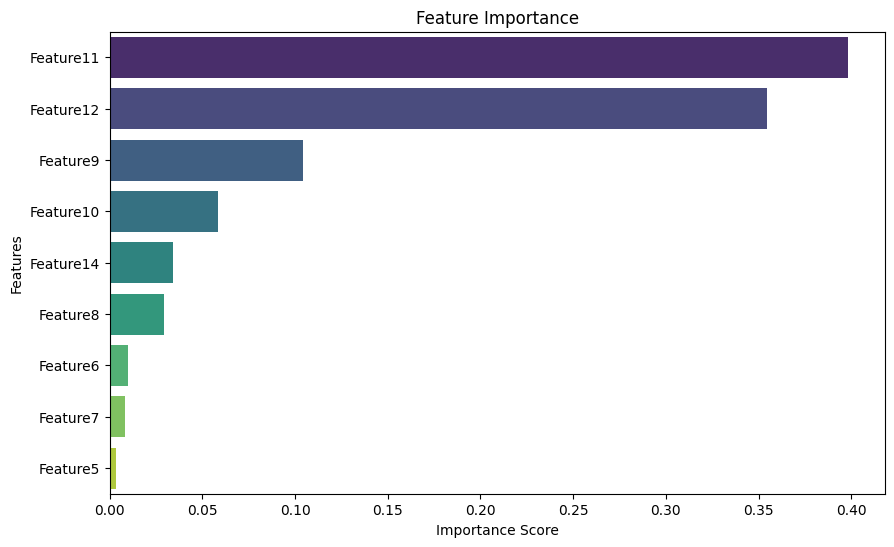

In [23]:
# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df['importance'], y=feature_importance_df['feature'], palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

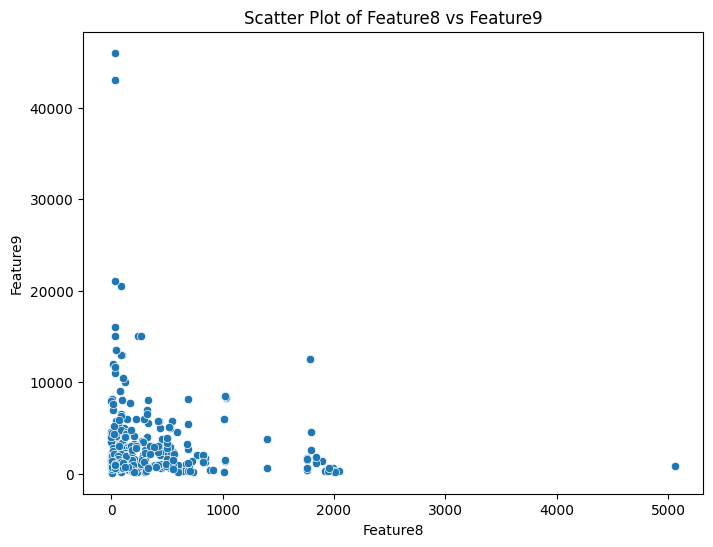

count     367.000000
mean      383.400545
std       551.671291
min         0.000000
25%        60.000000
50%       170.000000
75%       494.500000
max      5063.000000
Name: Feature8, dtype: float64

In [24]:
# Scatter plot
feature1 = 'Feature8'
feature2 = 'Feature9'
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_for_analysis[feature1], y=data_for_analysis[feature2])
plt.title(f'Scatter Plot of {feature1} vs {feature2}')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.show()
data_for_analysis['Feature8'].describe()

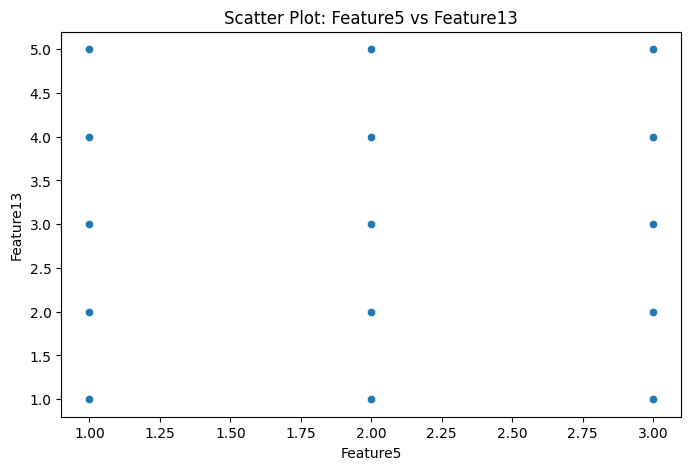

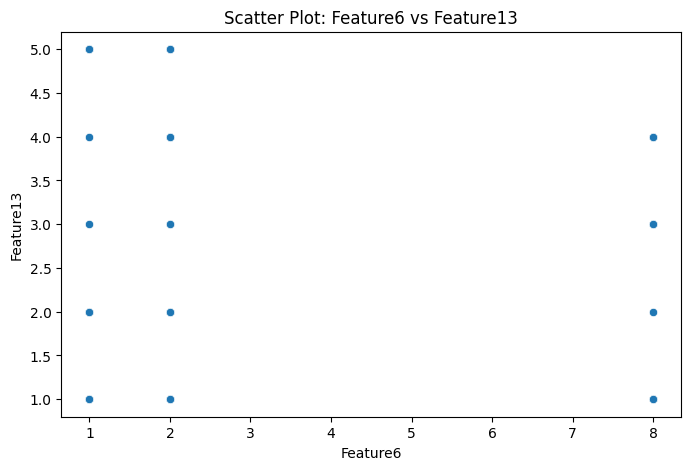

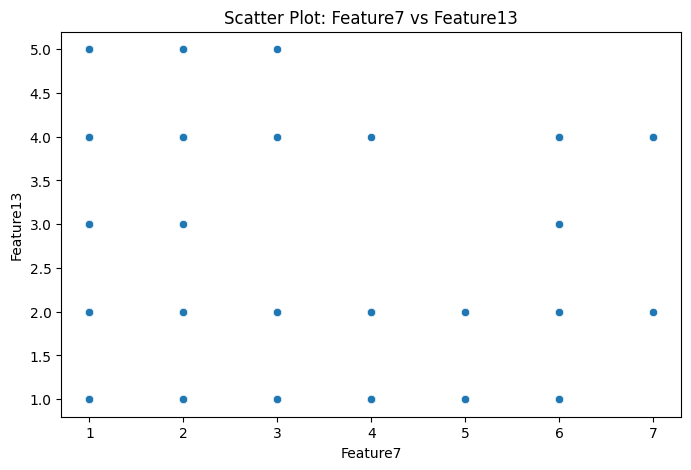

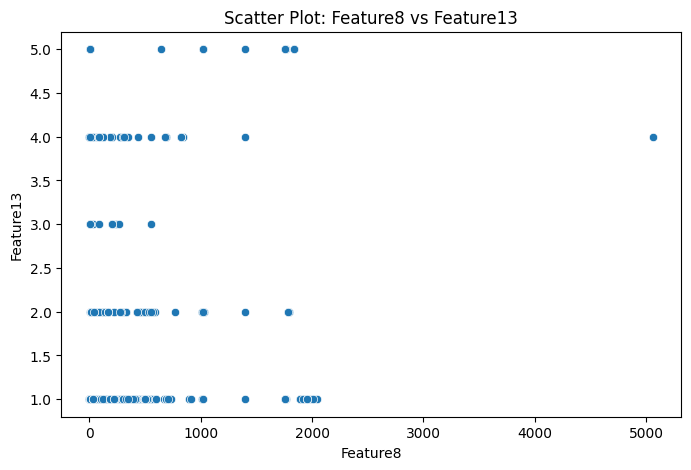

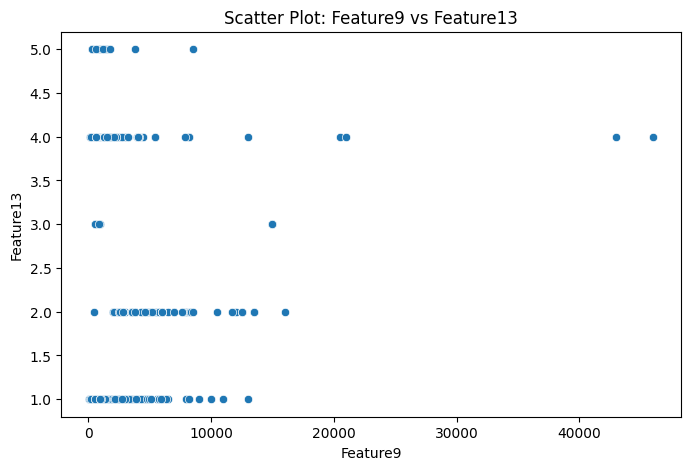

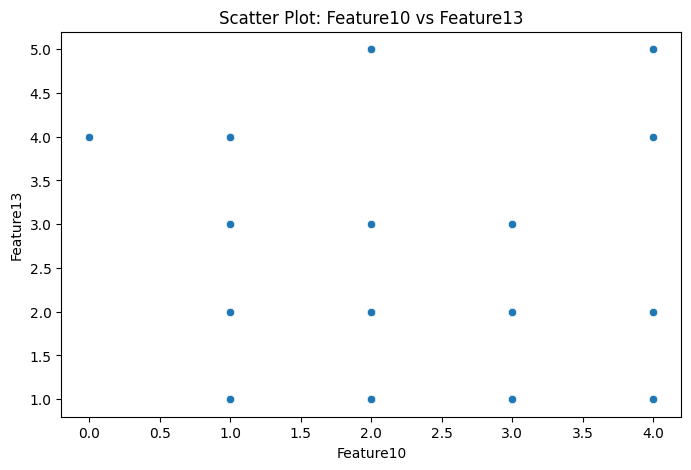

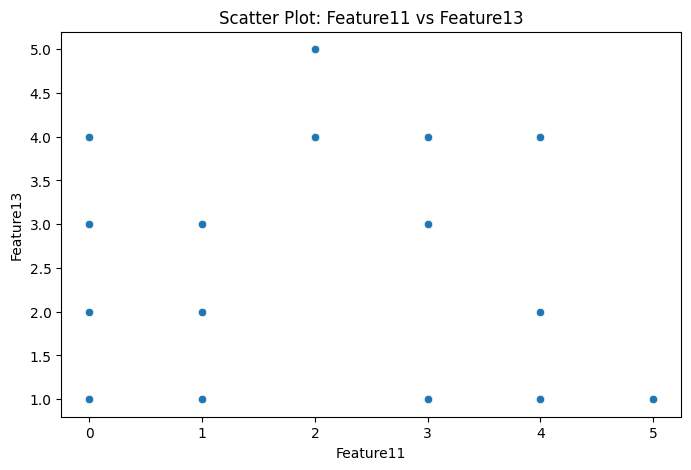

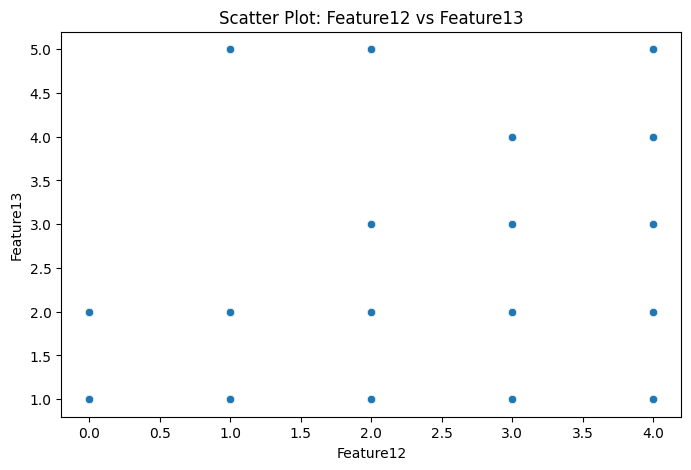

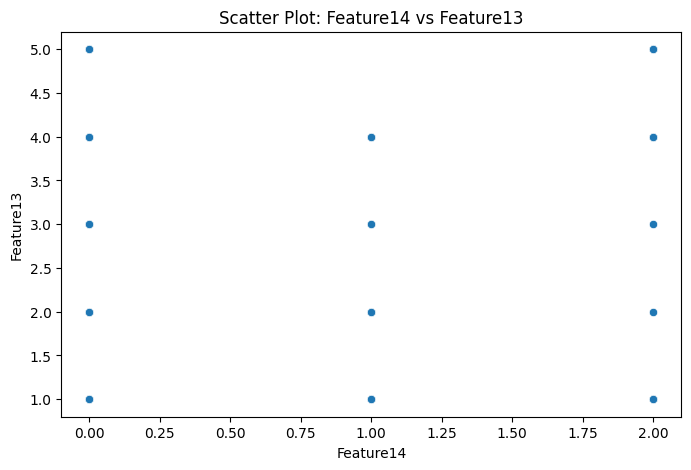

In [25]:
for feature in data_for_analysis.columns:
    if feature != target_column:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=data_for_analysis, x=feature, y=target_column)
        plt.title(f'Scatter Plot: {feature} vs {target_column}')
        plt.show()

In [26]:
data_for_analysis = data_for_analysis[(data_for_analysis['Feature9'] != 43000) & (data_for_analysis['Feature9'] != 46000)]
data_for_analysis = data_for_analysis[data_for_analysis['Feature8'] != 5063]

In [27]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column],axis=1)

# Select numerical features
numerical_features = x.select_dtypes(include=['int64', 'float64']).columns
print("Numerical features:", numerical_features)


In [28]:
# Standard deviation before scaling
x.std()

Feature5        0.814994
Feature6        3.013265
Feature7        1.484119
Feature8      495.703549
Feature9     3183.036332
Feature10       1.059984
Feature11       0.990323
Feature12       1.541608
Feature14       0.660661
dtype: float64

# Apply log transformation to all numerical features
# Shift values to make them positive
for feature in numerical_features:
    if feature not in object_cols:
        min_value = x[feature].min()
        if min_value <= 0:
            x[feature] = np.log1p(x[feature] - min_value + 1)
        else:
            x[feature] = np.log1p(x[feature])


# Check the transformed dataframe
x.head()


# List of features that were log-transformed
log_transformed_features = [feature for feature in numerical_features if feature not in object_cols]

# Plot the distribution of each log-transformed feature
for feature in log_transformed_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(x[feature], kde=True)
    plt.title(f'Distribution of {feature} after Log Transformation')
    plt.show()

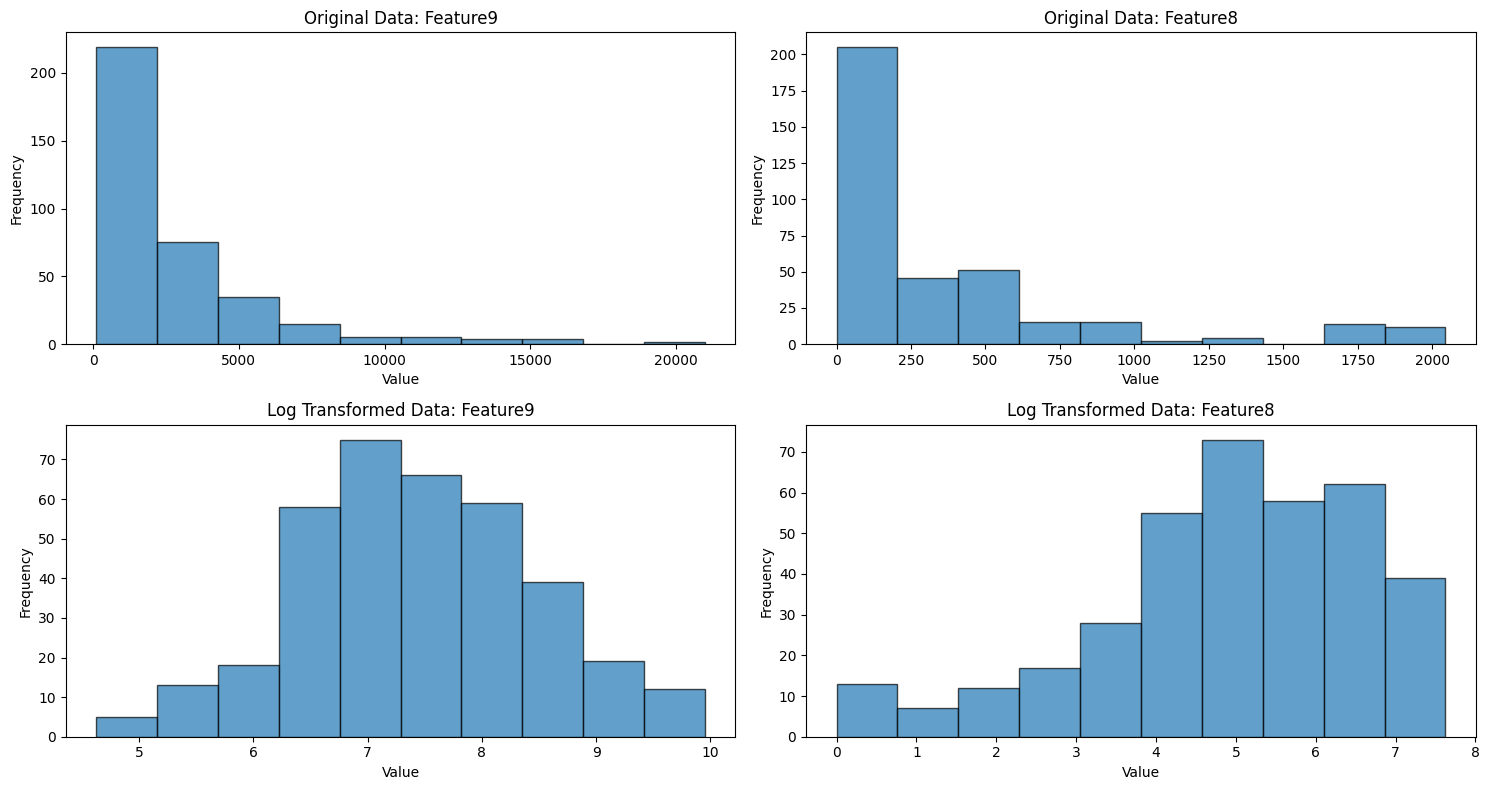

In [29]:
# Manually specify the numerical features
numerical_features = ['Feature9', 'Feature8']  # List of numerical columns to include
selected_data = data_for_analysis[numerical_features]

# Apply log transformation (add 1 to avoid log(0) issues)
log_transformed = selected_data.apply(lambda x: np.log1p(x))

# Plotting
fig, axes = plt.subplots(2, len(selected_data.columns), figsize=(15, 8))

# Titles for each transformation
titles = ["Original Data", "Log Transformed Data"]

# Loop through features and transformations
for i, col in enumerate(selected_data.columns):
    # Original Data
    axes[0, i].hist(selected_data[col], bins=10, edgecolor='k', alpha=0.7)
    axes[0, i].set_title(f"{titles[0]}: {col}")
    axes[0, i].set_xlabel("Value")
    axes[0, i].set_ylabel("Frequency")
    
    # Log Transformed Data
    axes[1, i].hist(log_transformed[col], bins=10, edgecolor='k', alpha=0.7)
    axes[1, i].set_title(f"{titles[1]}: {col}")
    axes[1, i].set_xlabel("Value")
    axes[1, i].set_ylabel("Frequency")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [30]:
data_for_analysis[numerical_features] = log_transformed

In [31]:
# apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
x_standardized = pd.DataFrame(scaled_features, columns=x.columns)

In [32]:
# standard deviation after scaling
x_standardized.std()

Feature5     1.001376
Feature6     1.001376
Feature7     1.001376
Feature8     1.001376
Feature9     1.001376
Feature10    1.001376
Feature11    1.001376
Feature12    1.001376
Feature14    1.001376
dtype: float64

In [33]:
x_standardized.columns

Index(['Feature5', 'Feature6', 'Feature7', 'Feature8', 'Feature9', 'Feature10',
       'Feature11', 'Feature12', 'Feature14'],
      dtype='object')

In [34]:
from sklearn.model_selection import train_test_split


def split_data(features, target, test_size=0.3, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(x, y)

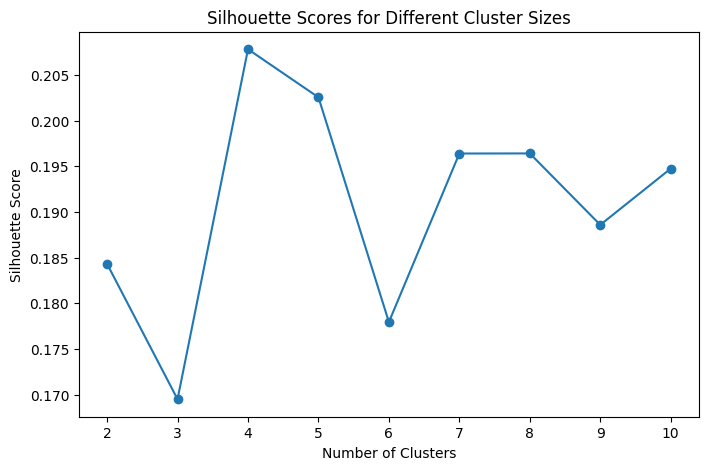

In [35]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
cluster_range = range(2, 11)

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(x_standardized)
    score = silhouette_score(x_standardized, kmeans_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title("Silhouette Scores for Different Cluster Sizes")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()


In [36]:
# Define number of clusters
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(x_standardized)

d:\master Automation & IT\winter semester 2024\case study Bartz\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


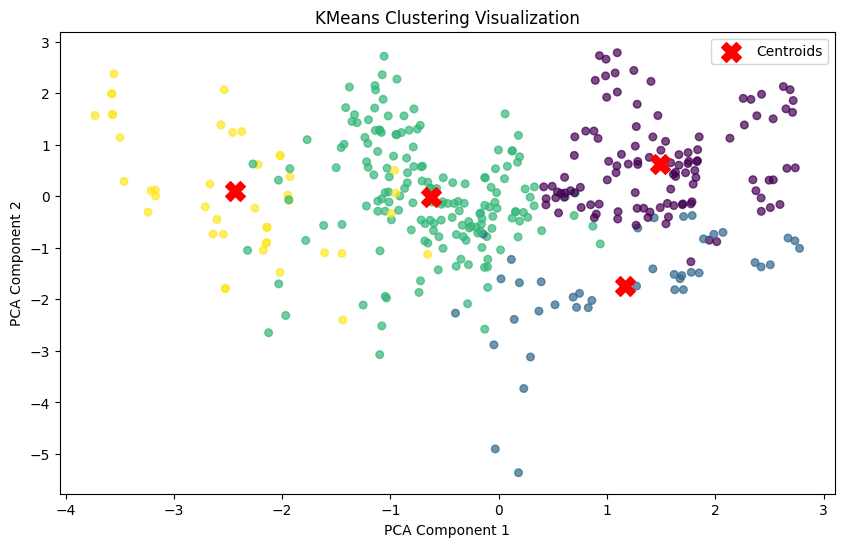

KMeans Silhouette Score: 0.21


In [37]:
# Apply PCA to reduce features to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_standardized)

# Transform the KMeans centroids using the same PCA transformation
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot the PCA-transformed data points
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30, alpha=0.7)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("KMeans Clustering Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

# Evaluate KMeans
kmeans_silhouette = silhouette_score(x_standardized, kmeans_labels)
print(f"KMeans Silhouette Score: {kmeans_silhouette:.2f}")


#### Gaussian Mixture Models

Best Silhouette Score: 0.1678 with 2 clusters


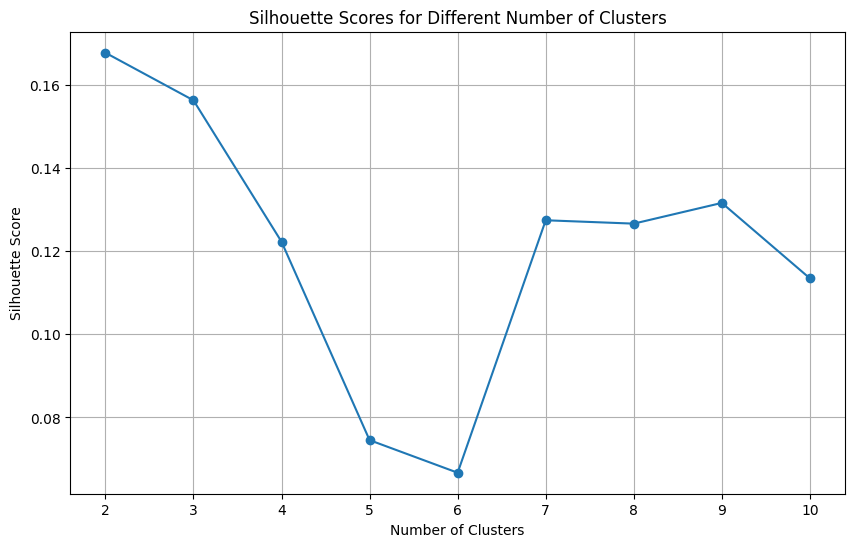

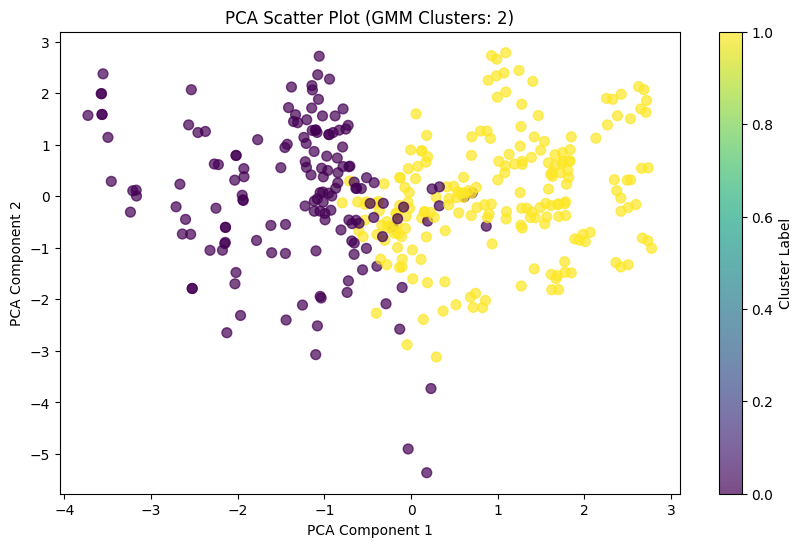

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Function to find the best number of clusters based on silhouette score
def gmm_clustering(X, max_clusters=10):
    best_score = -1
    best_n_clusters = 0
    silhouette_scores = []

    # Test different numbers of clusters
    for n_clusters in range(2, max_clusters + 1):
        gmm = GaussianMixture(n_components=n_clusters, random_state=20)
        labels = gmm.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)

        if score > best_score:
            best_score = score
            best_n_clusters = n_clusters

    print(f"Best Silhouette Score: {best_score:.4f} with {best_n_clusters} clusters")

    # Plot silhouette scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o')
    plt.title("Silhouette Scores for Different Number of Clusters")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()

    # Return the best model
    best_gmm = GaussianMixture(n_components=best_n_clusters, random_state=20)
    best_gmm.fit(X)
    return best_gmm, best_n_clusters

# Apply the GMM clustering and find the best number of clusters
gmm_model, n_clusters = gmm_clustering(x_standardized)

# Get the labels from the best GMM model
labels = gmm_model.predict(x_standardized)

# Perform PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_standardized)

# Plot the PCA scatter plot with clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title(f"PCA Scatter Plot (GMM Clusters: {n_clusters})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster Label")
plt.show()


### Hierarchical Clustering

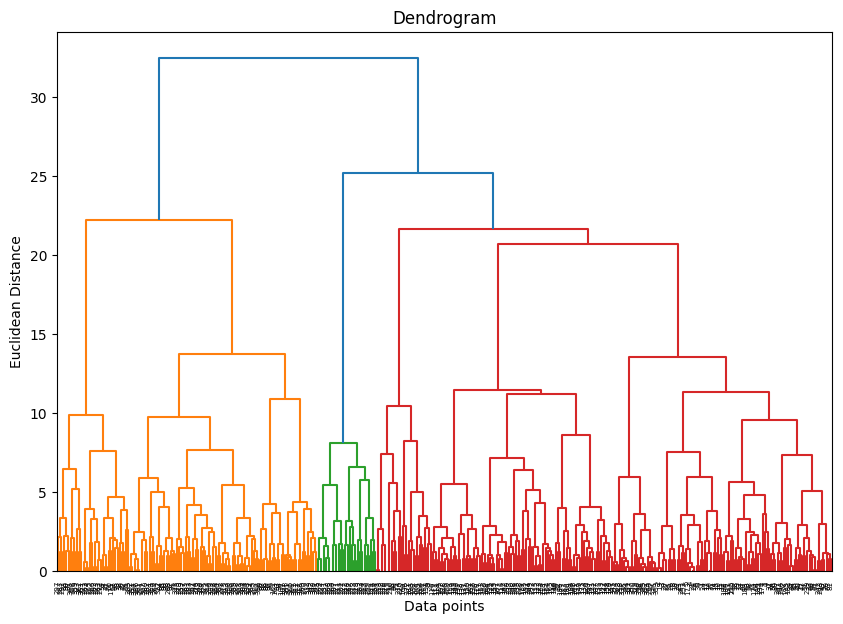

   Feature5  Feature6  Feature7  Feature8  Feature9  Feature10  Feature11  \
0 -1.289452 -0.660993 -0.873068 -0.742363 -0.680735  -0.739676   -0.41391   
1 -1.289452 -0.660993  1.151116 -0.324200 -0.617815  -0.739676   -0.41391   
2 -1.289452 -0.660993 -0.198340 -0.641358 -0.693319  -0.739676   -0.41391   
3 -1.289452 -0.660993  0.476388 -0.463588 -0.712195  -0.739676   -0.41391   
4 -0.060760 -0.660993 -0.873068 -0.685800  0.319686  -0.739676   -0.41391   

   Feature12  Feature14  Cluster  
0   0.701317   0.499688        0  
1   0.701317   0.499688        0  
2  -1.247381   0.499688        0  
3  -1.247381   0.499688        0  
4  -0.597815   0.499688        0  


In [ ]:
# Step 1: Import required libraries
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Step 2: Create the linkage matrix (using the 'ward' method)
Z = linkage(x_standardized, method='ward')

# Step 3: Plot the Dendrogram to visualize the clusters
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Euclidean Distance')
plt.show()

# Step 4: Determine the number of clusters (it can be choosed from the Dendrogram)
# For example, let's assume we choose 4 clusters (we can adjust this based on the dendrogram)
optimal_clusters = 4

# Step 5: Perform Hierarchical Clustering with the chosen number of clusters
hc = AgglomerativeClustering(n_clusters=optimal_clusters, linkage='ward')
clusters = hc.fit_predict(x_standardized)

# Step 6: Add the cluster labels to the original dataset
x_standardized['Cluster'] = clusters

# Display the first few rows with the cluster labels
print(x_standardized.head())

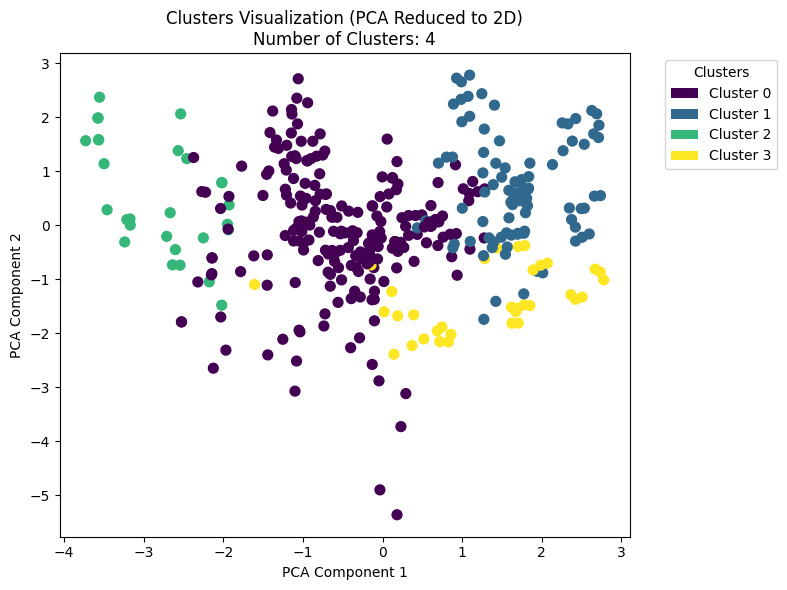

Hierarchical Silhouette Score: 0.1912351413220332


In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(x_standardized.drop(columns='Cluster'))

# Calculate the Silhouette Score
silhouette_avg = silhouette_score(x_standardized.drop(columns='Cluster'), x_standardized['Cluster'])

# Create a scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1], c=x_standardized['Cluster'], cmap='viridis', s=50)

# Extract the number of clusters
unique_clusters = np.unique(x_standardized['Cluster'])
num_clusters = len(unique_clusters)

# Add a title with the number of clusters
plt.title(f'Clusters Visualization (PCA Reduced to 2D)\nNumber of Clusters: {num_clusters}')

# Add labels for the axes
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Create a legend for cluster colors
legend_elements = [
    Patch(facecolor=scatter.cmap(scatter.norm(cluster)), label=f'Cluster {cluster}')
    for cluster in unique_clusters
]
plt.legend(handles=legend_elements, title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

print(f"Hierarchical Silhouette Score: {silhouette_avg}")